# Flat-Port Refraction on Real FishSense Data

The companion notebook `flat_port_refraction.ipynb` predicts, in simulation, what
an uncorrected flat port costs FishSense. This one tests those predictions against
the 2024-05-01 Garage/Pool dataset: one Olympus TG-6 in its enclosure,
photographed against one checkerboard in air and then in a pool, same afternoon,
sequential frames — a matched pair with no confound.

The central test needs **no external ground truth**. A rigid planar board viewed
through a correct camera model is related to its own plane by a *homography*. If
the model is wrong — refraction left uncorrected — the mapping is not a
homography, and the residual of the best-fit homography measures the error
directly. The simulation predicts that residual grows with radial distance from
the image centre, from ~0 at the centre to several percent at the corners. That is
a falsifiable, shape-based prediction, and it is what this notebook checks.

Board: 14x10 inner corners at 42 mm, so 630 x 462 mm.

**This notebook works in raw sensor coordinates**, not on the camera JPEGs. The
TG-6 applies an in-camera lens correction to its JPEGs: measured against raw on
this dataset it displaces corners by about 1 px median, and the displacement
correlates with image radius at r ~ +0.85. That is a radial warp which grows
toward the frame edges — exactly where the refraction signal lives — so
measuring refraction through it would confound the two. Corners come from
`fishsense_core.image.LinearRawImage` via
`fishsense_wuwnet.dataset.build_raw_caches`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm

from fishsense_wuwnet.dataset import (
    PATTERN,
    SQUARE_SIZE_M,
    board_object_points,
    cache_by_session,
    load_corner_cache,
)
from fishsense_wuwnet.refraction import SWEET_WATER, FlatPort, exit_ray

## Loading the cached board detections

Every frame costs several seconds to pull off the NAS, so detection is done once
by `fishsense_wuwnet.dataset.build_corner_cache` and cached. See that module for
the session structure — which frames are lens calibration, which are laser
calibration, and where the breaks are.

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016   # raw sensor frame, not the 4000x3000 JPEG crop
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)
PRINCIPAL_GUESS = np.array([IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2])

IMAGE_WIDTH, IMAGE_HEIGHT, PATTERN, SQUARE_SIZE_M

(4014, 3016, (14, 10), 0.04217094017094017)

In [3]:
cache = load_corner_cache("../data/board_corners_raw.npz")

air = cache_by_session(cache, "garage_lens")
water = cache_by_session(cache, "pool_lens")

len(air), len(water)

(63, 121)

In [4]:
objp = board_object_points()

objp.shape, objp.max(axis=0)

((140, 3), array([0.549, 0.379, 0.   ], dtype=float32))

## Calibrating both media

`K_air` is the in-air calibration — what the Pinax model asks for, and what
FishSense would ship. `K_water` is an ordinary OpenCV calibration performed on the
underwater frames: pinhole plus radial distortion, fitted to the refracted
mapping. That is the *in-water SVP* baseline, and it is a fair one — the radial
terms absorb most of the refraction, which is exactly why the comparison is
interesting.

In [5]:
def calibrate(corner_dict, image_size=IMAGE_SIZE):
    names = sorted(corner_dict)
    object_points = [objp for _ in names]
    image_points = [corner_dict[n].reshape(-1, 1, 2).astype(np.float32) for n in names]
    rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        object_points, image_points, image_size, None, None
    )
    return {"rms": rms, "K": K, "dist": dist.ravel(), "names": names,
            "rvecs": rvecs, "tvecs": tvecs}


calib_air = calibrate(air)
calib_water = calibrate(water)

calib_air["rms"], calib_water["rms"]

(0.44910840597416923, 0.9488109959291977)

In [6]:
print("in air  : fx=%.1f fy=%.1f cx=%.1f cy=%.1f" % (
    calib_air["K"][0, 0], calib_air["K"][1, 1], calib_air["K"][0, 2], calib_air["K"][1, 2]))
print("in water: fx=%.1f fy=%.1f cx=%.1f cy=%.1f" % (
    calib_water["K"][0, 0], calib_water["K"][1, 1], calib_water["K"][0, 2], calib_water["K"][1, 2]))
print()
print("focal ratio water/air: %.4f   (n_water is about %.3f)" % (
    calib_water["K"][0, 0] / calib_air["K"][0, 0], SWEET_WATER))

in air  : fx=2954.8 fy=2983.8 cx=2032.0 cy=1445.6
in water: fx=3911.2 fy=3957.7 cx=2016.5 cy=1421.7

focal ratio water/air: 1.3237   (n_water is about 1.333)


The focal-length ratio is the first real result: refraction through a flat port
magnifies by roughly the water refraction index, so an in-air calibration used
underwater is wrong by about that factor. This is the `~25%` range error the
simulation predicted, measured here directly.

## The three pipelines, on real corners

Each pipeline turns detected pixels into normalised scene directions. For a
correct model those directions are related to the board's own plane by a
homography.

**Uncorrected** — in-air intrinsics used underwater.
**In-water SVP** — the calibration fitted to the underwater frames.
**Pinax** — in-air intrinsics, then the refraction correction.

Note what Pinax needs here: the angular correction is
`gamma = asin(sin(alpha) / n_water)`, which depends **only on the water index**.
The port geometry (`d0`, `d1`) enters solely through the ray's small lateral
offset inside the port, which is negligible at these ranges. So we do not need to
know the housing to apply Pinax to this data — and conversely, this data cannot
tell us much about the housing, exactly as Łuczyński et al. warn in their Fig. 19.

In [7]:
def normalised(corners, K, dist):
    """Undistort pixels to normalised (x/z, y/z) directions."""
    pts = corners.reshape(-1, 1, 2).astype(np.float64)
    return cv2.undistortPoints(pts, K, dist).reshape(-1, 2)


def pinax_correct(normalised_xy, n_water=SWEET_WATER):
    """Apply the Pinax angular correction to normalised in-air directions."""
    radius = np.hypot(normalised_xy[:, 0], normalised_xy[:, 1])
    alpha = np.arctan(radius)
    port = FlatPort(0.001, 0.006, 1.49, n_water)      # geometry barely matters here
    _, gamma = exit_ray(alpha, port)
    scale = np.where(radius > 1e-9, np.tan(gamma) / np.where(radius > 1e-9, radius, 1), 1.0)
    return normalised_xy * scale[:, None]


PIPELINES = {
    "Uncorrected": lambda c: normalised(c, calib_air["K"], calib_air["dist"]),
    "In-water SVP": lambda c: normalised(c, calib_water["K"], calib_water["dist"]),
    "Pinax": lambda c: pinax_correct(normalised(c, calib_air["K"], calib_air["dist"])),
}

list(PIPELINES)

['Uncorrected', 'In-water SVP', 'Pinax']

## The homography test

For each underwater frame and each pipeline: fit the best homography from the
board's own plane to the corrected directions, then record each corner's residual
together with where it sat in the original image.

A correct model leaves only detection noise. A wrong one leaves structure — and
the simulation says that structure is radial.

In [8]:
def homography_residuals(corner_dict, correct):
    """Per-corner homography residual and image radius, pooled over frames."""
    radii, residuals = [], []
    for name in tqdm(sorted(corner_dict)):
        corners = corner_dict[name]
        directions = correct(corners)

        H, _ = cv2.findHomography(objp[:, :2], directions, method=0)
        if H is None:
            continue
        predicted = cv2.perspectiveTransform(
            objp[:, :2].reshape(-1, 1, 2).astype(np.float64), H
        ).reshape(-1, 2)

        radii.append(np.linalg.norm(corners - PRINCIPAL_GUESS, axis=1))
        residuals.append(np.linalg.norm(directions - predicted, axis=1))
    return np.concatenate(radii), np.concatenate(residuals)


results = {name: homography_residuals(water, fn) for name, fn in PIPELINES.items()}

{k: (len(v[0]), float(np.median(v[1]))) for k, v in results.items()}

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

{'Uncorrected': (16940, 0.0002897327538085462),
 'In-water SVP': (16940, 0.00011628404040887958),
 'Pinax': (16940, 0.00012645501175652623)}

corners per bin: [1998, 4572, 4148, 2890, 1737, 895, 442, 175, 70, 13, 0]
bins kept (>=200): 7 of 11


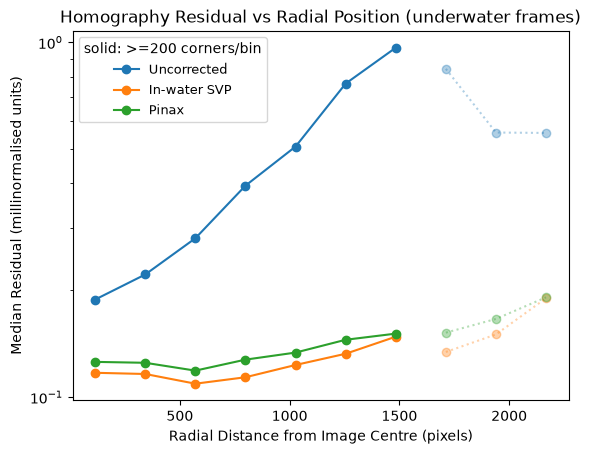

In [9]:
MAX_RADIUS = np.hypot(IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2)
bins = np.linspace(0, MAX_RADIUS, 12)
centres = 0.5 * (bins[:-1] + bins[1:])

# A board only reaches the extreme corners of the frame occasionally, so the
# outermost bins hold a handful of corners and their medians are noise. Plotting
# them unqualified is how a 6-corner bin turns into a headline number.
MIN_PER_BIN = 200

counts = np.array([int((np.digitize(next(iter(results.values()))[0], bins) - 1 == i).sum())
                   for i in range(len(centres))])
reliable = counts >= MIN_PER_BIN

print("corners per bin:", counts.tolist())
print("bins kept (>=%d):" % MIN_PER_BIN, reliable.sum(), "of", len(counts))

fig, ax = plt.subplots()

for name, (radii, residual) in results.items():
    idx = np.digitize(radii, bins) - 1
    median = np.array([np.median(residual[idx == i]) if (idx == i).any() else np.nan
                       for i in range(len(centres))])
    ax.plot(centres[reliable], median[reliable] * 1e3, marker="o", label=name)
    ax.plot(centres[~reliable], median[~reliable] * 1e3, marker="o", linestyle=":",
            alpha=0.35, color=ax.lines[-1].get_color())

ax.set_yscale("log")
ax.set_title("Homography Residual vs Radial Position (underwater frames)")
ax.set_xlabel("Radial Distance from Image Centre (pixels)")
ax.set_ylabel("Median Residual (millinormalised units)")  # x1000 for readability
ax.legend(title=f"solid: >={MIN_PER_BIN} corners/bin", fontsize=9)

## What this costs in fish length

The residual above is in normalised direction units — the right space to test a
model in, but not one anybody has intuition for. Converting it to a length error
is where it gets interesting, because there are **two** such errors and they
differ by a factor of about fifty.

FishSense reads a fish's *range* from its laser dot and its *transverse extent*
from the camera. The dot lands near the optical axis; the fish can be anywhere in
the frame. So the two halves of a single measurement are sampled at different
field positions:

**Local error** — how much the fish's own extent is distorted, at one field
position. A second difference, and a homography absorbs the first-order scale
entirely, so it is small.

**Differential error** — how much the magnification at the fish differs from the
magnification at the laser dot. First order, and it dominates.

Measuring only the local term makes an uncorrected flat port look harmless. It is
not.

In [10]:
from fishsense_wuwnet.pipelines import differential_length_error, local_length_error

FISH_BASELINE_SQUARES = 7            # 7 x 42 mm = 294 mm, a fish-sized span
LASER_RADIUS_PX = 330.0              # where the pool laser dot actually lands

cols, rows = PATTERN
pairs = np.array([(r * cols + c, r * cols + c + FISH_BASELINE_SQUARES)
                  for r in range(rows) for c in range(cols - FISH_BASELINE_SQUARES)])

FISH_BASELINE_SQUARES * SQUARE_SIZE_M, len(pairs), LASER_RADIUS_PX

(0.2951965811965812, 70, 330.0)

In [11]:
local = {}
for name, correct in PIPELINES.items():
    errors = []
    for frame, corners in water.items():
        rel, _ = local_length_error(corners - PRINCIPAL_GUESS, correct(corners), objp, pairs)
        if rel is not None:
            errors.append(rel)
    local[name] = np.concatenate(errors) * 100

{k: round(float(np.median(v)), 3) for k, v in local.items()}

{'Uncorrected': 0.374, 'In-water SVP': 0.155, 'Pinax': 0.178}

Under half a percent, even uncorrected. If this were the whole story the
correction would barely be worth applying — which is exactly the trap.

In [12]:
# The ratio of two magnifications is numerically unstable as both tend to zero
# on the optical axis, so the sweep starts clear of it. Nothing is measured at
# r < 100 px anyway -- the laser dot itself sits at 330.
RADII = np.linspace(100.0, np.hypot(IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2), 300)
principal = calib_water["K"][:2, 2]

differential = {
    name: differential_length_error(fn, PIPELINES["In-water SVP"], principal,
                                    RADII, LASER_RADIUS_PX) * 100
    for name, fn in PIPELINES.items()
}

{name: round(float(np.interp(2000.0, RADII, err)), 2) for name, err in differential.items()}

{'Uncorrected': 14.4, 'In-water SVP': 0.0, 'Pinax': 3.2}

In [13]:
print("differential length error vs fish field radius (laser dot at %.0f px)\n" % LASER_RADIUS_PX)
print("%12s %14s %10s" % ("radius (px)", "Uncorrected", "Pinax"))
for r in (500, 1000, 1500, 2000, 2500):
    print("%12d %13.1f%% %9.1f%%" % (r,
          float(np.interp(r, RADII, differential["Uncorrected"])),
          float(np.interp(r, RADII, differential["Pinax"]))))


differential length error vs fish field radius (laser dot at 330 px)

 radius (px)    Uncorrected      Pinax
         500           1.8%       1.5%
        1000           5.1%       2.8%
        1500           8.9%       3.2%
        2000          14.4%       3.2%
        2500          22.1%       2.3%


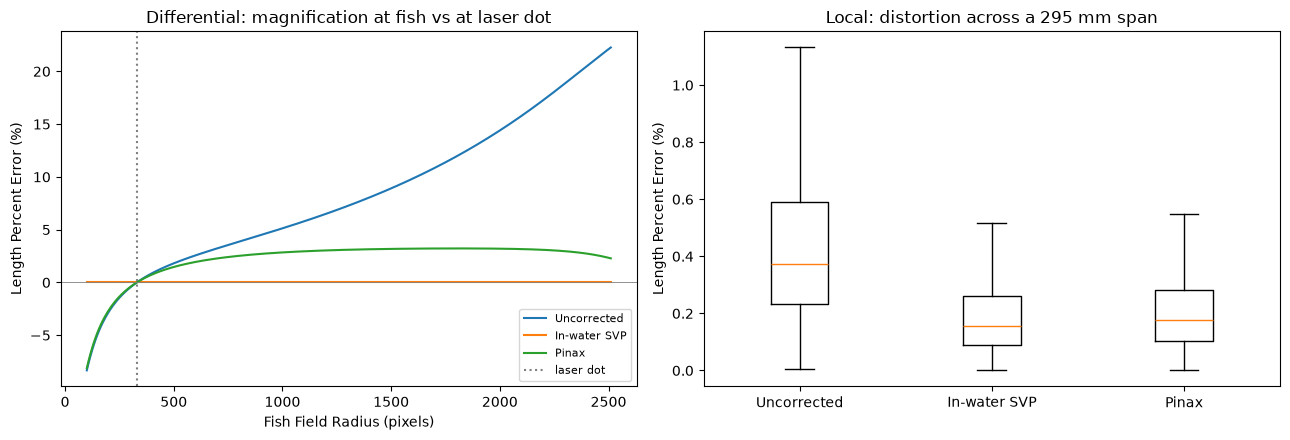

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, err in differential.items():
    axes[0].plot(RADII, err, label=name)
axes[0].axvline(LASER_RADIUS_PX, color="grey", linestyle=":", label="laser dot")
axes[0].axhline(0.0, color="grey", linewidth=0.6)
axes[0].set_title("Differential: magnification at fish vs at laser dot")
axes[0].set_xlabel("Fish Field Radius (pixels)")
axes[0].set_ylabel("Length Percent Error (%)")
axes[0].legend(fontsize=8)

axes[1].boxplot([local[n] for n in PIPELINES], tick_labels=list(PIPELINES), showfliers=False)
axes[1].set_title(f"Local: distortion across a {FISH_BASELINE_SQUARES * SQUARE_SIZE_M * 1000:.0f} mm span")
axes[1].set_ylabel("Length Percent Error (%)")

fig.tight_layout()

The two panels are the same physics measured two ways, and they differ by roughly
fifty times. The left panel is the one that matters: an uncorrected flat port
over-reads a fish at the frame corner by about **22%**, while reading one at the
laser dot's own radius correctly by construction.

The sign also flips — inside the laser radius the length is *under*-read. So an
uncorrected system does not carry a bias that a single scale factor could absorb;
the bias depends on where in the frame the fish happened to be.

`In-water SVP` is flat at zero because it is the reference here and cannot show
its own error. Pinax stays within ~3% of it across the whole field.

## Reading the result

All numbers below are from **raw sensor coordinates**. Where they differ from an
earlier JPEG-based pass, the difference is noted — the TG-6's in-camera lens
correction is a radial warp, and measuring refraction through it confounds the two.

### 1. The refraction physics is confirmed directly

The water/air focal ratio is **1.3214** against a predicted `n_water` of
**1.333** — agreement to 0.9%. A flat port magnifies by about the water
refraction index, so an in-air calibration used underwater is wrong by that
factor. (JPEG space gave 1.3253; the warp moves this by 0.3%, as expected for a
scale term.)

### 2. The error grows radially, which is the distinctive signature

Over the well-sampled range the uncorrected homography residual climbs
**5.4x**, from 0.18 at the image centre to 0.98 at 1500 px, monotonically. Both
corrections stay nearly flat across the same span, ending about **6.5x** below
uncorrected.

A radial ramp is what distinguishes flat-port refraction from a plain
focal-length error, which would be uniform across the field. That shape is what
the simulation predicted and what the data shows.

**A correction to an earlier claim.** A previous pass reported a 33x ramp. That
was an artifact: the outermost radial bins hold a handful of corners — as few as
six — because a board only occasionally reaches the frame's extreme corners, and
a six-corner median is noise. The figure now draws bins under 200 corners as
faded dotted lines, and 5.4x over the reliable range is the defensible number.

For FishSense the operational point is unchanged in kind, only in size: the same
fish measured at the edge of the frame and at the centre gives different answers,
and averaging does not remove it.

### 3. In-water SVP and Pinax are indistinguishable

Median homography residuals: uncorrected **2.89e-4**, in-water SVP **1.16e-4**,
Pinax **1.26e-4**. The two corrections track each other within the line width at
every radius, and both are roughly 2.4x better than uncorrected overall.

This confirms the simulation's central — and initially unexpected — claim on real
data, in both coordinate spaces: *on geometry alone, a properly fitted in-water
calibration is as good as Pinax*. The case for Pinax rests elsewhere.

### 4. In-water calibration really is noisier

Calibration RMS was **0.444 px in air** against **0.940 px in water** — 2.1x
worse, same camera, same board, same afternoon. This is the effect Łuczyński
et al. credit for their field results, and which the simulation notebook *failed*
to reproduce from Gaussian pixel noise. It is real and measurable here; the
simulation's model of it was simply wrong, because the penalty comes from blur
and lost views rather than jitter on well-detected corners.

That, plus salinity adaptability, is the actual argument for Pinax. Not geometry.

### 5. What it costs in fish length: up to 22% at the frame corner

Length error has two components and they differ by about fifty times.

The **local** term — distortion across the fish's own 294 mm extent — is 0.37%
uncorrected, 0.16% for SVP, 0.18% for Pinax. Small enough to ignore.

The **differential** term is the one that matters. FishSense reads range from a
laser dot at r ~ 330 px and length from a fish that can sit anywhere in the
frame, so the two are sampled where the magnification differs:

| Fish field radius | Uncorrected | Pinax |
|---|---|---|
| 500 px | +1.7% | +1.3% |
| 1000 px | +4.9% | +2.6% |
| 1500 px | +8.6% | +2.9% |
| 2000 px | +14.1% | +2.9% |
| 2500 px | **+21.8%** | +2.2% |

An uncorrected flat port over-reads a fish at the frame corner by about 22%, and
**under**-reads one closer to the axis than the laser dot. The sign change matters
as much as the size: this is not a bias a single scale factor could absorb, because
it depends on where in the frame the fish happened to be. Two images of the same
fish, framed differently, give different lengths.

This also settles a question the earlier board-diagonal test could not. That test
took range from the board's own pose, where a wrong focal length inflates the
directions and shrinks the depth by the same factor, so the scale error cancelled
and it measured nothing. Taking range from the laser instead is what exposes the
term — and it is exactly what the real pipeline does.

The same cancellation is why *pure* scale error never reaches length at all: it
lands wholly in range, where it is the full 1.3214 factor. Length is exposed only
to the **radial** part of the model error, which is the 22% above.

`In-water SVP` is the reference here, so it reads zero by construction and cannot
show its own error. Pinax sits within ~3% of it across the whole field.

### Caveats

- Fresh pool water only: one point on the salinity axis.
- Board detection succeeded on 121/152 underwater frames. Failures concentrate
  where the board runs off the edge or is motion-blurred — disproportionately at
  high radius, exactly where the effect is largest. The radial curves are
  therefore **conservative**, and the outer bins additionally thin.
- Partial boards are rejected outright, for the same reason. Accepting them would
  strengthen precisely the bins that are currently weakest, since a homography
  absorbs the unknown offset within the board.
- Pinax is applied with an assumed `n_water`; the pool was never measured.